In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "5d733eab198ad58f23ceee3f1550014385366ece"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/5d733eab198ad58f23ceee3f1550014385366ece/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Baselines and Variance Reduction

The REINFORCE estimator of that section is unbiased, and it found the optimal FrozenLake policy. It is also wasteful. A trajectory that never reaches the goal has $R(\tau) = 0$ and drops out of the estimator entirely, so early in training most of the robot's experience produces no learning signal at all, and the updates that do arrive swing the parameters around a lot. In this section we reduce the variance of the estimator without changing what it estimates. We first drop terms whose average is zero anyway, then subtract a reference value from the rest, and finally learn that reference value per state. Each step keeps the estimator unbiased and each step makes the same episode budget go further.

## A Zero-Mean Identity

Everything in this section rests on one small fact about the score function.

**Lemma.** For every state $s$, $\ \sum_{a \in \mathcal{A}} \pi_\theta(a \mid s)\ \nabla_\theta \log \pi_\theta(a \mid s) = 0$.

**Proof.** $\sum_a \pi_\theta(a \mid s) \nabla_\theta \log \pi_\theta(a \mid s) = \sum_a \nabla_\theta\, \pi_\theta(a \mid s) = \nabla_\theta \sum_a \pi_\theta(a \mid s) = \nabla_\theta 1 = 0.$ $\blacksquare$

In words: at any state, the score of the sampled action has zero mean. The useful consequence is slightly stronger. Suppose $c$ is any quantity that is already determined by the time the robot stands at state $s_t$: a reward collected earlier in the trajectory, a constant, or a function of $s_t$ itself. Conditioned on the trajectory prefix $(s_0, a_0, r_0, \ldots, s_t)$, the value $c$ is fixed while the action $a_t$ is still random, and since the policy consults only $s_t$, the inner expectation is the one the lemma covers:

$$E\big[ c\ \nabla_\theta \log \pi_\theta(a_t \mid s_t) \big] = E\Big[ c\ \underbrace{E\big[ \nabla_\theta \log \pi_\theta(a_t \mid s_t) \mid s_0, a_0, \ldots, s_t \big]}_{=\,0 \textrm{ by the lemma}} \Big] = 0.$$

We can therefore multiply any score in the REINFORCE estimator by such a quantity, or subtract such a quantity from its weight, without moving the average. Both tools of this section are instances of this observation.

## Reward-to-Go

Look at what multiplies the score at time $t$ in the REINFORCE estimator: the return $R(\tau_i)$ of the whole trajectory, including rewards that were collected *before* the robot took the action $a_t^i$. The action did not cause those rewards. By the observation above, each product of a past reward with the score at time $t$ has zero mean; it contributes nothing to the gradient on average and adds variance for free. Dropping all such terms from $\nabla_\theta J(\theta)$ leaves

$$\nabla_\theta J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \Big[ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t \mid s_t)\ \sum_{t'=t}^{T-1} \gamma^{t'} r_{t'} \Big].$$

The inner sum equals $\gamma^t \hat{G}_t$ where

$$\hat{G}_t = \sum_{t'=t}^{T-1} \gamma^{t'-t}\, r_{t'}$$

is called the reward-to-go from step $t$: the discounted return of the remainder of the trajectory, as if it started at $s_t$. Implementations almost always drop the leading $\gamma^t$ and weight the score at step $t$ by $\hat{G}_t$ alone, which treats every timestep equally instead of down-weighting late ones. Sutton and Barto's boxed REINFORCE keeps the factor, and their text derivation sidesteps the question by treating the undiscounted case; we follow implementation practice instead, and the price is that the simplified update is no longer an exact unbiased estimate of the gradient of the discounted objective. The estimator becomes

$$\hat{u} = \frac{1}{n} \sum_{i=1}^n \sum_{t=0}^{T-1} \hat{G}_t^i\ \nabla_\theta \log \pi_\theta(a_t^i \mid s_t^i).$$

This refinement is sometimes summarized by the word causality: the policy's choice at time $t$ can only influence rewards from time $t$ onward, so only those rewards should judge it.

## Baselines

The second use of the identity is subtraction. Any quantity $b$ that does not depend on the action $a_t$, whether a constant or a function $b(s_t)$ of the current state, can be subtracted from the reward-to-go without biasing the estimator:

$$\hat{u} = \frac{1}{n} \sum_{i=1}^n \sum_{t=0}^{T-1} \big( \hat{G}_t^i - b(s_t^i) \big)\ \nabla_\theta \log \pi_\theta(a_t^i \mid s_t^i).$$

Such a $b$ is called a baseline. The extra term is $b(s_t)$ times the score, and we showed above that this has zero mean, so the equation and the equation estimate the same gradient.

Why subtract anything? On FrozenLake every reward is $0$ or $1$, so every $\hat{G}_t$ is non-negative and the estimator can only push probabilities up, by amounts that differ across trajectories. A baseline near the typical return changes the sign structure: steps that went better than typical get positive weight, steps that went worse get negative weight, and a failed trajectory finally says something, namely "do this less". The baseline can be a fixed number, the average return seen so far, or a learned estimate of the value function; averaging what the robot has seen is not the variance-optimal choice, but it is simple and it captures most of the benefit. The baseline that minimizes the variance exactly can be worked out in closed form, and we leave it as an exercise.

## Control Variates

Subtracting a baseline is an instance of a standard trick from Monte Carlo estimation called a control variate. The idea needs no reinforcement learning at all, so let us first state it on its own.

You want to estimate the average of a noisy quantity $X$ from samples. Suppose that alongside each sample of $X$ you can also observe a second quantity $Y$, and that two things hold: $Y$ tends to move together with $X$, and you know the true average $E[Y]$ exactly. Then every sample carries a hint about its own noise. If $Y$ came out above its known average, and the two quantities move together, then this sample of $X$ is probably too high as well, and by an amount you can gauge from how far $Y$ overshot. So correct each sample: subtract the observed excess of $Y$, scaled by a factor $c$ of your choosing,

$$X_c = X - c\, \big( Y - E[Y] \big).$$

The correction averages to zero, because $E[Y - E[Y]] = 0$. So $X_c$ has the same mean as $X$ no matter what $c$ is: we can pick $c$ freely without biasing the estimate. What changes is the noise. Expanding the variance of the difference,

$$\mathrm{Var}(X_c) = \mathrm{Var}(X) - 2c\, \mathrm{Cov}(X, Y) + c^2\, \mathrm{Var}(Y),$$

which is a parabola in $c$. Setting its derivative to zero gives the best factor,

$$c^* = \frac{\mathrm{Cov}(X, Y)}{\mathrm{Var}(Y)},$$

and substituting $c^*$ back in leaves the variance at $(1 - \rho^2)\, \mathrm{Var}(X)$, where $\rho$ is the correlation between $X$ and $Y$. The formula says exactly how much the trick buys: the more strongly the two quantities co-vary, the more noise the correction cancels. At $\rho = 0.9$ the variance falls by a factor of about five. At $\rho = 0$ the correction does nothing. The quantity $Y$ is called a control variate for $X$.

Now place the baseline in this picture. The noisy quantity we average at step $t$ is the score scaled by the reward-to-go,

$$X = \hat{G}_t\, \nabla_\theta \log \pi_\theta(a_t \mid s_t),$$

and the second quantity is the score by itself,

$$Y = \nabla_\theta \log \pi_\theta(a_t \mid s_t).$$

$Y$ moves together with $X$ almost by construction, since $X$ is $Y$ times a scalar. And we know the true average of $Y$ exactly: it is zero, by the lemma. The scale factor is the baseline itself, $c = b(s_t)$. Line up the pieces and the equation is the equation, term by term: a baseline is a control variate built from the score.

The reframing pays twice. First, unbiasedness for every $b$ stops being a lucky algebraic fact; it is the any-$c$-is-allowed property that every control variate has. Second, the question of which baseline is best now has an exact answer: the optimal scale is $c^*$, the covariance-over-variance ratio, computed state by state. Carried out for the vector-valued score, where the products become inner products, it gives the score-weighted optimal baseline of the exercises. The plain average return has the right scale but is not that exact optimum, which is why it is good without being best. @Greensmith.Bartlett.Baxter.2004 develop this view for policy gradient estimators and show that the value-function critic of that section can be read as a control variate as well.

## Normalized Returns

A practical variant standardizes the reward-to-go values within each batch. Collect every $\hat{G}_t^i$ in the current batch, compute their mean $\mu$ and standard deviation $\sigma$, and use

$$\tilde{G}_t^i = \frac{\hat{G}_t^i - \mu}{\sigma + \epsilon}$$

in place of $\hat{G}_t^i$, where the small constant $\epsilon$ avoids dividing by zero. Subtracting $\mu$ acts as a baseline, with one caveat: $\mu$ is computed from the same batch, so it depends weakly on the sampled actions, and the exact zero-bias argument above holds only up to a correction that vanishes as the batch grows. Dividing by $\sigma + \epsilon$ is different in kind: it rescales the update so that its size no longer depends on the scale of the rewards, which spares us from re-tuning the learning rate every time the reward magnitudes change.

The reason to dwell on this variant is what it became. Group Relative Policy Optimization (GRPO), the method used to train recent reasoning language models, samples a *group* of $G$ responses to the same prompt, scores each response with a reward $r_j$, and weights the score function with

$$A_j = \frac{r_j - \mu}{\sigma + \epsilon},$$

where $\mu$ and $\sigma$ are the mean and standard deviation of the rewards within the group. This is the equation, with the prompt in the role of our start state and the group of responses in the role of our batch of $n$ trajectories. Even the motivation is the one from this section, read at scale: for a model with billions of parameters, a learned baseline of the kind we build next is a value network as large as the policy and as hard to train, so GRPO drops it and lets the group mean act as a per-prompt baseline, while the group standard deviation makes advantages comparable across prompts whose reward magnitudes differ. GRPO adds machinery around the update itself, which that section will explain, but its advantage estimate is this subsection's normalization, nothing more.

## A Learned Baseline

The best baseline at state $s$ should say what return is typical *from that state*, and the chapter already has a name for that quantity: the value function $V^{\pi_\theta}(s)$ from that section. We do not know it, but we can estimate it from the same batch of trajectories. Keep a table $\hat{V}(s)$, and after each batch move the estimate at every visited state toward the reward-to-go observed there,

$$\hat{V}(s_t) \leftarrow \hat{V}(s_t) + \beta \big( \hat{G}_t - \hat{V}(s_t) \big),$$

with a step size $\beta$. The weight in the equation becomes $\hat{G}_t - \hat{V}(s_t)$, which reads as: how much better did the trajectory do from $s_t$ than trajectories usually do from $s_t$. A quantity of this form is called an advantage, and this algorithm is REINFORCE with a baseline [@Williams.1992]. Note that $\hat{V}$ is trained here by regression on Monte Carlo returns, meaning reward-to-go values computed from complete sampled trajectories; in that section we will let it build its targets from its own predictions instead, and the pair of a parameterized policy and a learned value estimate will get a name of its own.

## Comparing the Variants

We now run the four estimators against each other on FrozenLake: the plain trajectory return of that section, reward-to-go the equation, normalized reward-to-go the equation, and reward-to-go with the learned baseline. To make the comparison fair, every variant uses the same batch size and the same learning rate.

In [1]:

%matplotlib inline
import numpy as np
import random
from d2l import torch as d2l

gamma = 0.95  # Discount factor
num_iters = 150  # Gradient ascent updates per run
batch_size = 4  # Trajectories per update; small on purpose, to expose variance
alpha = 2.0  # Learning rate, identical for all variants
beta = 0.1  # Step size for the learned value baseline
num_seeds = 5  # Independent runs per variant

env_info = d2l.make_env('FrozenLake-v1', seed=0)
env = env_info['env']
num_states = env_info['num_states']
num_actions = env_info['num_actions']

The helpers are the same as in that section, except that the sampler now returns the whole reward sequence so that we can compute reward-to-go:

In [2]:

def softmax_policy(theta, s):
    e = np.exp(theta[s] - np.max(theta[s]))
    return e / e.sum()

def sample_trajectory(env, theta):
    state, _ = env.reset()
    states, actions, rewards, done = [], [], [], False
    while not done:
        probs = softmax_policy(theta, state)
        action = np.random.choice(len(probs), p=probs)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        state = next_state
    return states, actions, rewards

def reward_to_go(rewards, gamma):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    return out[::-1]

One training function covers all four variants; they differ only in the weight placed on each score:

In [3]:

def train(variant, seed):
    env.reset(seed=seed)
    env.action_space.seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    theta = np.zeros((num_states, num_actions))
    V = np.zeros(num_states)  # Only used by the learned-baseline variant
    success = []
    for it in range(num_iters):
        steps, reached = [], []
        for _ in range(batch_size):
            S, A, R = sample_trajectory(env, theta)
            reached.append(R[-1] > 0)
            G = reward_to_go(R, gamma)
            for t, (s, a) in enumerate(zip(S, A)):
                # Weight on the score at step t: full return vs. reward-to-go
                w = G[0] if variant == 'return' else G[t]
                steps.append((s, a, w))
        success.append(np.mean(reached))
        W = np.array([w for _, _, w in steps])
        if variant == 'normalized':
            W = (W - W.mean()) / (W.std() + 1e-8)
        elif variant == 'learned baseline':
            W = np.array([w - V[s] for s, _, w in steps])
            for s, _, g in steps:
                V[s] += beta * (g - V[s])
        u = np.zeros_like(theta)
        for (s, a, _), w in zip(steps, W):
            grad = -softmax_policy(theta, s)
            grad[a] += 1.0
            u[s] += w * grad
        theta += alpha * u / batch_size
    return np.array(success)

variants = ['return', 'reward-to-go', 'normalized', 'learned baseline']
curves = {v: np.stack([train(v, seed) for seed in range(num_seeds)])
          for v in variants}

We plot, for every variant, the batch success rate over training, averaged over the seeds, with a band of one standard deviation across seeds. A window of ten updates smooths each curve first.

return: median updates to reach 90% success = 69
reward-to-go: median updates to reach 90% success = 43
normalized: median updates to reach 90% success = 32
learned baseline: median updates to reach 90% success = 46


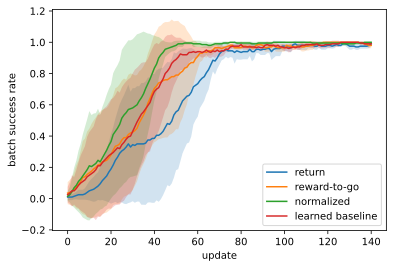

In [4]:

d2l.compare_success_curves(curves)

The ordering matches the theory. Plain trajectory returns are the slowest, a median of about 69 updates to reach a 90% success rate in this run. Reward-to-go cuts that to about 45. Normalization brings it to about 33, roughly half of what the plain estimator needs. The learned baseline lands next to reward-to-go here, around 46, and the reason it does not win on this problem is plain: rewards are sparse, so $\hat{V}$ stays near zero until the robot has reached the goal a few times, and until then the learned-baseline variant *is* reward-to-go. Its payoff is the per-state advantage view, which that section builds on.

The figure also demonstrates how results in reinforcement learning should be read. Every band in the plot is wide. On the plain-return variant, individual seeds in this experiment reached the 90% mark anywhere between update 39 and update 87, more than a factor of two apart, with nothing changed but the random seed. A single training curve is an anecdote; had we shown you the luckiest seed of the slowest variant next to the unluckiest seed of the fastest one, the conclusion would have flipped. When you compare algorithms, run several seeds, plot the spread, keep the hyper-parameters matched, and report medians rather than best runs. We kept the learning rate at $2.0$ for all four variants above for exactly this reason.

## Summary

The REINFORCE estimator pairs every score with the whole trajectory return, and much of that pairing averages to zero. The zero-mean property of the score function lets us drop rewards from before an action and subtract any action-independent baseline, both without bias. Reward-to-go judges each action by what came after it. A baseline turns "push everything up by different amounts" into "push good steps up and bad steps down". Normalizing the reward-to-go values inside a batch additionally makes the step size insensitive to reward scale. Estimating the baseline per state with a value table produces advantage-weighted updates and is one bootstrap away from the actor-critic method of that section. Finally, learning curves in reinforcement learning are noisy; conclusions require several seeds and matched hyper-parameters, not one lucky run.

## Exercises

1. In the equation, replace the full normalization by mean subtraction alone, i.e., use $\hat{G}_t - \mu$ without dividing by $\sigma + \epsilon$. Compare all three of raw, mean-subtracted, and fully normalized reward-to-go at a couple of learning rates. Which part of the improvement comes from centering and which from rescaling?
1. Vary the baseline step size $\beta$ (e.g., $0.01$, $0.1$, $0.5$). How sensitive is the learned-baseline variant to it, and what goes wrong when $\beta$ is too large?
1. For a single state and a constant baseline $b$, the variance of the estimator is minimized not by the average return but by a weighted average, $b^* = E[\|\nabla_\theta \log \pi_\theta(a \mid s)\|^2\, \hat{G}] \,/\, E[\|\nabla_\theta \log \pi_\theta(a \mid s)\|^2]$. Derive this by differentiating the variance with respect to $b$, and check that it is the optimal coefficient $c^*$ derived after the equation, carried over to the vector-valued score.
1. Repeat the comparison on the $8 \times 8$ FrozenLake map. Does the gap between the variants grow or shrink, and why would you expect that from the length of the trajectories?